### Toy example: Newsvendor problem

#### Imports

In [1]:
import numpy as np
import math
from numpy.random import choice
from sklearn.utils import shuffle
import itertools
from scipy.stats import dirichlet
from tqdm import tqdm
from joblib import Parallel, delayed
import time

from bayesian_dro.Bayesian_DRO_continuous import (
    main_Bayesian_DRO, data_generation, xi_generation, theta_generation, main_Bayesian_DRO_epsilon1
)

#### Class for sampling from the NPL posterior (Assumes a Exponential distribution model)


In [2]:
# NPL class
class npl():
    """This class contains functions to perform NPL inference (for alpha = 0 in the DP prior) for the Exponential distribution model.
    The user supplies parameters:
        X: Data set
        B: number of bootstrap iterations
        p: number of unknown parameters
        loss_fn : string set to 'wll' or 'mmd' to specify either the negative log-lkh or mmd-based loss function 
    """

    def __init__(self, X, B, p, loss_fn='wll'):
        self.B = B
        self.X = X
        self.p = p
        self.loss_fn = loss_fn
        self.n, self.d = self.X.shape

    def draw_samples(self):
        """Draws B samples in parallel from the nonparametric posterior"""

        weights = dirichlet.rvs(np.ones(self.n), size = self.B, random_state = 13)
        samples = np.zeros((self.B,self.p))
        
        if self.loss_fn == 'wll':
            # FIXME n_jobs > 1
            temp = Parallel(n_jobs=1, backend='multiprocessing', max_nbytes=None,batch_size="auto")(delayed(self.WLL)(self.X,weights[i,:]) for i in range(self.B))

            for i in range(self.B):
                  samples[i,:] = temp[i]
                  self.sample = np.array(samples)
        elif self.loss_fn == 'mmd':
            # FIXME implement NPL-MMD here / 1 is just a dummy value for now! 
            self.sample = 1 #np.loadtxt('mmd_samples.txt')

    def WLL(self, data, weights):
        """Get weighted negative log likelihood minimizer, for Exponential distribution model"""

        theta = np.zeros(self.d)
        for i in range(self.n):
            theta += weights[i]*data[i,:]
        return 1/theta

#### Sample observations from DGP

In [14]:
from scipy.stats import truncnorm
# set random seed
myseed = np.random.seed(0)

my_mean = 20
my_std = 4
# Sample observations
# degrees_of_freedom = 2
num_observations = 1000
# data_student_t = np.random.standard_t(degrees_of_freedom, size=num_observations)
def data_generation(num_observations):
    """True DGP"""
    myclip_a, myclip_b = 0, np.inf

    a, b = (myclip_a - my_mean) / my_std, (myclip_b - my_mean) / my_std
    data = truncnorm.rvs(a, b, loc=my_mean, scale=my_std, size=num_observations)
    return data
# DGP is a truncated normal
data = data_generation(num_observations)
data.shape

(1000,)

### Alaternative function to sample observations with outliers

In [15]:
from scipy.stats import truncnorm
from sklearn.utils import shuffle
from scipy.stats import expon

myseed = np.random.seed(0)
my_mean = 20
my_std = 1
n_cont = 0.2
num_observations = 1000
def data_generation_outliers(num_observations, n_cont):
    """True DGP"""
    cont_size = int(np.floor(n_cont*num_observations))
    n_real = num_observations - cont_size

    # myclip_a, myclip_b = 0, np.inf

    # a, b = (myclip_a - my_mean) / my_std, (myclip_b - my_mean) / my_std
    # data = truncnorm.rvs(a, b, loc=my_mean, scale=my_std, size=n_real)

    # outl = truncnorm.rvs(a, b, loc=my_mean+20, scale=my_std, size=cont_size)

    data = expon.rvs(scale=10, size=n_real)
    outl = expon.rvs(scale=70, size=cont_size)
     
    data = np.concatenate((data, outl), axis=0)
    
    return data

# DGP is a truncated normal with outliers
# data = data_generation_outliers(num_observations, n_cont)
# data = shuffle(data)
# data.shape

Plot observations

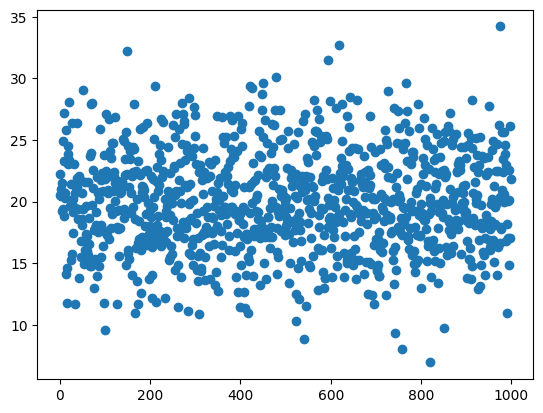

In [16]:
import matplotlib.pyplot as plt
plt.scatter(range(num_observations), data)

#### Generate NPL posterior samples

In [17]:
n = num_observations
B = 1000 # number of bootstrap iterations
p = 1 # numbers of unknown parameters

npl_toy = npl(data.reshape((n,1)),B, p, loss_fn='wll')  # can change loss_fn to wll or mmd
t0 = time.time()
npl_toy.draw_samples()
t1 = time.time()
total = t1-t0
print(f'Total time: {total} seconds')
sample = npl_toy.sample

Total time: 1.1244490146636963 seconds


## Bayesian DRO with NPL Posterior

Sample $\theta$ from the NPL posterior, then apply Bayesian DRO algorithm.

In [18]:
EPSILON = 1.0   # fix epsilon for now
theta_npl = sample
xi = np.zeros([B, num_observations])
for i in range(B):
    xi[i] = xi_generation(theta_npl[i], num_observations)
#solution_BDRO_NPL = main_Bayesian_DRO(xi, EPSILON)
solution_epsilon_1_npl, epsilon_1_dro = main_Bayesian_DRO_epsilon1(data, theta_npl, xi)

/Users/cdellaporta/Desktop/mis-dro-code/bayesian_dro/Bayesian_DRO_continuous.py:210: RuntimeWarning: overflow encountered in exp
  np.mean(np.exp(cost(x, xi[theta_index, :]) / lam))
/Users/cdellaporta/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


In [19]:
# solution_BDRO_NPL
solution_epsilon_1_npl

44.71999999999986

## Bayesian DRO

In [21]:
EPSILON = 1.0   # fix epsilon for now
theta = theta_generation(data, B)
xi = np.zeros([B, num_observations])
for i in range(B):
    xi[i] = xi_generation(theta[i], num_observations)
# solution_BDRO = main_Bayesian_DRO(xi, EPSILON)
solution_epsilon_1, epsilon_1_dro = main_Bayesian_DRO_epsilon1(data, theta, xi)

In [22]:
#solution_BDRO
solution_epsilon_1

45.30999999999974

Cost function

In [24]:
b = 4
h = 3
def cost(x, xi):
    return h * np.maximum(0, x - xi) + b * np.maximum(0, xi - x)

In [25]:
# Some new data to approximate true expected cost
myseed = np.random.seed(20)
#data_eval = data_generation_outliers(10000, 0)
data_eval = data_generation(10000)
# cost_BDRO_NPL = cost(solution_BDRO_NPL, data_eval)
# cost_BDRO = cost(solution_BDRO, data_eval)
cost_BDRO_NPL = cost(solution_epsilon_1_npl, data_eval)
cost_BDRO = cost(solution_epsilon_1, data_eval)
print(cost_BDRO_NPL.mean(), cost_BDRO.mean())
print(cost_BDRO_NPL.std(), cost_BDRO.std())

74.10667810128356 75.8766781012832
2.9983403258755073 2.9983403258755073


Perform experiment for K = 200 replications and calculate out-of-sample mean and variance 

In [96]:
myseed_eval = np.random.seed(20) # change for each j
test_num_obs = 10000
data_eval = data_generation(test_num_obs)
K = 200 
num_observations = 1000
B = 1000 # number of bootstrap iterations
p = 1 # numbers of unknown parameters
EPSILON = 1.0
cost_bayes = np.zeros((K,2))
cost_npl = np.zeros((K,2))

for j in tqdm(range(K)):
    myseed = np.random.seed(j)
    data = data_generation(num_observations)
    npl_toy = npl(data.reshape((n,1)),B, p, loss_fn='wll')  # can change loss_fn to wll or mmd
    npl_toy.draw_samples()
    npl_theta_sample = npl_toy.sample
    bayes_theta_sample = theta_generation(data, B)
    xi_bayes = np.zeros([B, num_observations])
    xi_NPL = np.zeros([B, num_observations])
    for i in range(B):
        xi_bayes[i] = xi_generation(bayes_theta_sample[i], num_observations)
        xi_NPL[i] = xi_generation(npl_theta_sample[i], num_observations)
    solution_BDRO = main_Bayesian_DRO(xi_bayes, EPSILON)
    solution_BDRO_NPL = main_Bayesian_DRO(xi_NPL, EPSILON)
    cost_bayes_current = cost(solution_BDRO, data_eval)
    cost_npl_current = cost(solution_BDRO_NPL, data_eval)
    cost_bayes[j,:] = cost_bayes_current.mean(), cost_bayes_current.std()**2
    cost_npl[j,:] = cost_npl_current.mean(), cost_npl_current.std()**2
    
# Calculate out-of-sample mean and variance
mean_bayes = cost_bayes[:,0].mean()
var_bayes = cost_bayes[:,1].mean() + (1/(K-1))*np.sum((cost_bayes[:,0]-mean_bayes)**2)
mean_npl = cost_npl[:,0].mean()
var_npl = cost_npl[:,1].mean() + (1/(K-1))*np.sum((cost_npl[:,0]-mean_npl)**2)
print(f'BDRO has out-of-sample mean: {mean_bayes} and out-of-sample variance: {var_bayes}')
print(f'BDRO-NPL has out-of-sample mean: {mean_npl} and out-of-sample variance: {var_npl}')


 18%|█▊        | 36/200 [19:53<1:30:00, 32.93s/it]/Users/cdellaporta/Library/Python/3.9/lib/python/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
100%|██████████| 200/200 [1:50:00<00:00, 33.00s/it]

BDRO has out-of-sample mean: 46.83532301023784 and out-of-sample variance: 148.19237060827953
BDRO-NPL has out-of-sample mean: 46.892389236439215 and out-of-sample variance: 146.9086461303539
